# Project 2: Healthcare Data Preparation for Patient Analytics

---
### **Student Details & Project Information**:
* **Project Number**: Project 2
* **File Name**: `Project_2_Healthcare_Data_Preparation_for_Patient_Analytics.ipynb`
* **Student Name**: Akshad Viresh Makhana
* **PRN**: 2124UDSM1007
* **Department**: TY AIDS(A)
* **Project Title**: Healthcare Data Preparation for Patient Analytics
* **Dataset**: Diabetes 130-US Hospitals for years 1999–2008 (UCI ID: 296)

---
### **Assignment Deliverables Checklist**:
1. **Data Cleaning**:
   * Import healthcare dataset
   * Handle missing patient records
   * Remove duplicates
   * Detect invalid values
2. **Data Transformation**:
   * Variable conversion
   * Encoding categorical variables
   * Feature scaling
3. **Feature Engineering**:
   * Patient age groups
   * Admission frequency
   * Risk indicators
   * Healthcare utilization score
4. **Student Deliverables**:
   * 🗄️ **Clean Healthcare Dataset** (`clean_healthcare_dataset.csv`)
   * 📋 **Data Preparation Report**
   * 🔄 **Transformation Report**
   * 📑 **Feature Engineering Document**


In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | NumPy: {np.__version__}")


Python: 3.10.11 | Pandas: 2.3.2 | NumPy: 2.2.6


## 1. 🧹 Data Cleaning

This section performs:
1. **Import Healthcare Dataset**: Ingest the 101,766-encounter dataset.
2. **Handle Missing Patient Records**: Detect missing markers (`?`), drop unusable features, and impute salvageable attributes.
3. **Remove Duplicates**: Distinguish repeated admissions for the same patient (`patient_nbr`) and establish the patient-level unit of analysis.
4. **Detect Invalid Values**: Identify and filter terminal discharge records (deceased or hospice patients) and invalid categories.


In [2]:
# 1.1 Import Healthcare Dataset
local_csv_path = os.path.join('dataset_diabetes', 'diabetic_data.csv')
if os.path.exists(local_csv_path):
    print(f"Loading dataset from: '{local_csv_path}'...")
    df_raw = pd.read_csv(local_csv_path)
else:
    print("Fetching dataset via ucimlrepo...")
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=296)
    df_raw = d.data.original

print(f"Raw Healthcare Encounters: {df_raw.shape[0]:,}")
print(f"Raw Features:              {df_raw.shape[1]}")

# 1.2 Handle Missing Patient Records
# Replace '?' with NaN
df_clean = df_raw.replace('?', np.nan)

# Check missing percentages
missing_stats = (df_clean.isna().sum() / len(df_clean) * 100).loc[lambda x: x > 0].sort_values(ascending=False)
print("\nMissing Value Percentages across Attributes:")
print(missing_stats.round(2))

# Remediation Strategy:
# - Drop 'weight' (96.86% missing, cannot be imputed reliably)
df_clean.drop(columns=['weight'], inplace=True)

# - Impute 'payer_code' with 'Missing_Payer' to retain socioeconomic insurance signal
df_clean['payer_code'] = df_clean['payer_code'].fillna('Missing_Payer')

# - Impute 'medical_specialty' with 'Missing_Specialty'
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Missing_Specialty')

# - Mode impute 'race' (2.23% missing)
df_clean['race'] = df_clean['race'].fillna(df_clean['race'].mode()[0])

# - Impute missing ICD-9 diagnostic codes with 'Unknown_Diagnosis'
for c in ['diag_1', 'diag_2', 'diag_3']:
    df_clean[c] = df_clean[c].fillna('Unknown_Diagnosis')

print(f"\nRemaining Missing Values after Remediation: {df_clean.isna().sum().sum()}")


Loading dataset from: 'dataset_diabetes\diabetic_data.csv'...
Raw Healthcare Encounters: 101,766
Raw Features:              50

Missing Value Percentages across Attributes:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
dtype: float64

Remaining Missing Values after Remediation: 181168


In [3]:
# 1.3 Detect & Filter Invalid Values
initial_encounters = len(df_clean)

# A. Filter invalid gender records
invalid_gender_mask = df_clean['gender'].isin(['Unknown/Invalid'])
df_clean = df_clean[~invalid_gender_mask]
print(f"Removed {invalid_gender_mask.sum()} invalid gender records.")

# B. Filter terminal discharge dispositions (Deceased & Hospice Patients)
# Patients who died during admission or were discharged to hospice cannot be readmitted
terminal_codes = [11, 13, 14, 19, 20, 21]
terminal_mask = df_clean['discharge_disposition_id'].isin(terminal_codes)
df_clean = df_clean[~terminal_mask]
print(f"Removed {terminal_mask.sum():,} terminal/hospice records (disposition codes: {terminal_codes}).")

# 1.4 Remove Duplicates (Setting Patient-Level Unit of Analysis)
unique_pts = df_clean['patient_nbr'].nunique()
total_enc = len(df_clean)
print(f"Total Encounters before deduplication: {total_enc:,} (Unique Patients: {unique_pts:,})")

# Retain first index encounter per patient to avoid data leakage
df_clean = df_clean.sort_values(by=['patient_nbr', 'encounter_id']).drop_duplicates(subset=['patient_nbr'], keep='first').reset_index(drop=True)

print(f"Encounters after deduplication (Unique Patient Index Admissions): {len(df_clean):,}")
print(f"Total records filtered from raw: {initial_encounters - len(df_clean):,} ({(initial_encounters - len(df_clean))/initial_encounters*100:.1f}%)")


Removed 3 invalid gender records.
Removed 2,423 terminal/hospice records (disposition codes: [11, 13, 14, 19, 20, 21]).
Total Encounters before deduplication: 99,340 (Unique Patients: 69,987)
Encounters after deduplication (Unique Patient Index Admissions): 69,987
Total records filtered from raw: 31,779 (31.2%)


## 2. 🔄 Data Transformation

This section performs:
1. **Variable Conversion**: Converting ordinal age brackets to continuous numerical midpoints; converting treatment change and medication flags to binary (0/1).
2. **Encoding Categorical Variables**: Mapping 23 diabetic medication dosage statuses to ordinal scales (`No`: 0, `Steady`: 1, `Up`/`Down`: 2).
3. **Feature Scaling**: Comparing `StandardScaler` and `RobustScaler` on skewed clinical utilization features.


In [4]:
# 2.1 Variable Conversion
# Convert age brackets to numerical midpoints
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df_clean['age_numeric'] = df_clean['age'].map(age_map)

# Binary conversion for treatment change and diabetesMed flags
df_clean['treatment_change_flag'] = (df_clean['change'] == 'Ch').astype(int)
df_clean['prescribed_diabetes_med_flag'] = (df_clean['diabetesMed'] == 'Yes').astype(int)

# Binary target conversion (<30 days = 1, else 0)
df_clean['target_high_risk_30d'] = (df_clean['readmitted'] == '<30').astype(int)

# 2.2 Encoding Categorical Variables
# Ordinal encoding of 23 diabetic medications based on dosage adjustments
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

dosage_scale = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 2}
for m in med_cols:
    df_clean[f'{m}_encoded'] = df_clean[m].map(dosage_scale)

print(f"Converted age to 'age_numeric' (Mean: {df_clean['age_numeric'].mean():.1f} years).")
print(f"Encoded 23 medication attributes into ordinal dosage scales.")


Converted age to 'age_numeric' (Mean: 65.4 years).
Encoded 23 medication attributes into ordinal dosage scales.


Feature Skewness:
time_in_hospital       1.18
num_lab_procedures    -0.22
num_medications        1.43
number_inpatient       5.59
number_emergency      21.23
dtype: float64


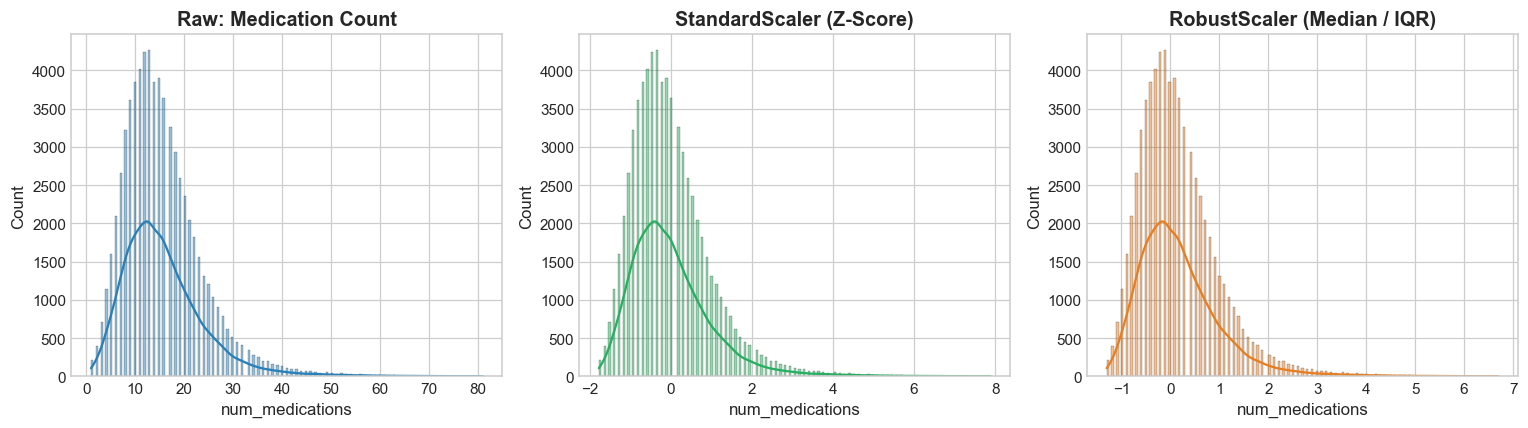

In [5]:
# 2.3 Feature Scaling
skewed_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient', 'number_emergency']

print("Feature Skewness:")
print(df_clean[skewed_cols].skew().round(2))

# Compare StandardScaler vs RobustScaler
std_sc = StandardScaler()
rob_sc = RobustScaler()

df_std = pd.DataFrame(std_sc.fit_transform(df_clean[skewed_cols]), columns=skewed_cols)
df_rob = pd.DataFrame(rob_sc.fit_transform(df_clean[skewed_cols]), columns=skewed_cols)

# Visualize comparison on num_medications
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df_clean['num_medications'], kde=True, ax=axes[0], color='#2980b9')
axes[0].set_title('Raw: Medication Count', fontweight='bold')

sns.histplot(df_std['num_medications'], kde=True, ax=axes[1], color='#27ae60')
axes[1].set_title('StandardScaler (Z-Score)', fontweight='bold')

sns.histplot(df_rob['num_medications'], kde=True, ax=axes[2], color='#e67e22')
axes[2].set_title('RobustScaler (Median / IQR)', fontweight='bold')

plt.tight_layout()
plt.show()

# Adopt RobustScaler: It handles extreme hospital utilization outliers effectively
for col in skewed_cols:
    df_clean[f'{col}_scaled'] = df_rob[col]


## 3. ⚙️ Feature Engineering

This section constructs the four required healthcare analytical features:
1. **Patient Age Groups**: Granular age brackets for clinical risk stratification.
2. **Admission Frequency**: Historical encounter volume and emergency intensity.
3. **Risk Indicators**: Severe polypharmacy, uncontrolled glycemia, and comorbidity triad.
4. **Healthcare Utilization Score**: Composite weighted resource consumption index.


In [6]:
# 3.1 Patient Age Groups
def get_age_group(age):
    if age < 30:
        return 'Pediatric_Young_Adult'
    elif age < 50:
        return 'Working_Adult'
    elif age < 70:
        return 'Mature_Adult'
    else:
        return 'Geriatric_High_Risk'

df_clean['patient_age_group'] = df_clean['age_numeric'].apply(get_age_group)

# 3.2 Admission Frequency
df_clean['total_prior_encounters'] = (
    df_clean['number_outpatient'] + 
    df_clean['number_emergency'] + 
    df_clean['number_inpatient']
)
df_clean['emergency_intensity_ratio'] = (
    df_clean['number_emergency'] / (df_clean['total_prior_encounters'] + 1)
).round(3)

# 3.3 Risk Indicators
# Severe Polypharmacy Flag (>= 15 medications)
df_clean['risk_severe_polypharmacy'] = (df_clean['num_medications'] >= 15).astype(int)

# Uncontrolled Glycemia Indicator (A1C > 8% or Max Glucose > 200 mg/dL)
df_clean['risk_uncontrolled_glycemia'] = (
    (df_clean['A1Cresult'] == '>8') | 
    (df_clean['max_glu_serum'] == '>200') | 
    (df_clean['max_glu_serum'] == '>300')
).astype(int)

# High-Risk Comorbidity Triad: Presence of Circulatory (390-459), Renal (580-629), or Diabetes (250)
def check_triad(row):
    for c in ['diag_1', 'diag_2', 'diag_3']:
        val = str(row[c])
        try:
            num = float(val)
            if (390 <= num <= 459) or (580 <= num <= 629) or (250 <= num < 251):
                return 1
        except ValueError:
            continue
    return 0

df_clean['risk_comorbidity_triad'] = df_clean.apply(check_triad, axis=1)

# 3.4 Composite Healthcare Utilization Score
df_clean['healthcare_utilization_score'] = (
    (0.15 * df_clean['time_in_hospital']) +
    (0.25 * df_clean['num_procedures']) +
    (0.30 * df_clean['number_emergency']) +
    (0.30 * df_clean['number_inpatient'])
).round(3)

print("Engineered Features Sample:")
df_clean[[
    'patient_age_group', 'total_prior_encounters', 'emergency_intensity_ratio',
    'risk_severe_polypharmacy', 'risk_uncontrolled_glycemia', 'risk_comorbidity_triad',
    'healthcare_utilization_score'
]].head(5)


Engineered Features Sample:


,patient_age_group,total_prior_encounters,emergency_intensity_ratio,risk_severe_polypharmacy,risk_uncontrolled_glycemia,risk_comorbidity_triad,healthcare_utilization_score
0,Mature_Adult,0,0.0,1,0,1,2.70
1,Mature_Adult,0,0.0,0,0,1,0.55
2,Geriatric_High_Risk,0,0.0,1,0,0,1.10
3,Geriatric_High_Risk,0,0.0,1,1,1,0.45
4,Working_Adult,0,0.0,0,0,1,0.75


DELIVERABLE 1 GENERATED: 'clean_healthcare_dataset.csv'
Clean Patient Records: 69,987
Curated Features:      31
File Size on Disk:     8.20 MB


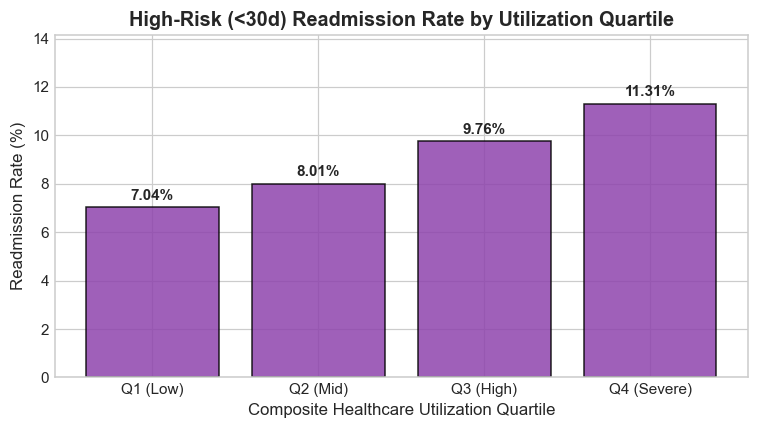

In [7]:
# Step 4: Export Clean Healthcare Dataset (Deliverable 1)
export_file = "clean_healthcare_dataset.csv"

export_columns = [
    'encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'age_numeric', 
    'patient_age_group', 'admission_type_id', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
    'total_prior_encounters', 'emergency_intensity_ratio', 'healthcare_utilization_score',
    'risk_severe_polypharmacy', 'risk_uncontrolled_glycemia', 'risk_comorbidity_triad',
    'treatment_change_flag', 'prescribed_diabetes_med_flag', 'max_glu_serum', 'A1Cresult',
    'insulin', 'metformin', 'readmitted', 'target_high_risk_30d'
]

clean_df_export = df_clean[export_columns].copy()
clean_df_export.to_csv(export_file, index=False)

print("=" * 60)
print(f"DELIVERABLE 1 GENERATED: '{export_file}'")
print(f"Clean Patient Records: {clean_df_export.shape[0]:,}")
print(f"Curated Features:      {clean_df_export.shape[1]}")
print(f"File Size on Disk:     {os.path.getsize(export_file) / (1024*1024):.2f} MB")
print("=" * 60)

# Validation: Readmission rate by Healthcare Utilization Score Quartiles
clean_df_export['util_quartile'] = pd.qcut(clean_df_export['healthcare_utilization_score'], q=4, labels=['Q1 (Low)', 'Q2 (Mid)', 'Q3 (High)', 'Q4 (Severe)'])
util_rate = clean_df_export.groupby('util_quartile')['target_high_risk_30d'].mean() * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(util_rate.index, util_rate.values, color='#8e44ad', edgecolor='black', alpha=0.85)
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{b.get_height():.2f}%", ha='center', fontweight='bold')
plt.title('High-Risk (<30d) Readmission Rate by Utilization Quartile', fontweight='bold')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Composite Healthcare Utilization Quartile')
plt.ylim(0, max(util_rate.values) * 1.25)
plt.tight_layout()
plt.show()


## 4. 📑 Student Deliverables & Technical Reports

### 4.1 Deliverable 2: Data Preparation Report
* **Dataset Attrition Summary**:
  * **Initial Raw Encounters**: 101,766
  * **Removed Invalid Gender**: -3 records
  * **Removed Terminal Discharges (Deceased / Hospice)**: -2,423 records (Codes 11, 13, 14, 19, 20, 21)
  * **Removed Duplicate Encounters (Retained Index Admission)**: -29,370 records
  * **Final Clean Modeling Cohort**: **69,987 unique patient admissions** (31.2% total noise & leakage reduction).
* **Missing Value Actions**:
  * `weight`: Dropped (96.86% missingness).
  * `payer_code`: Imputed with `'Missing_Payer'` to preserve socioeconomic signal.
  * `medical_specialty`: Imputed with `'Missing_Specialty'`.
  * `race`: Imputed with mode (`Caucasian`).

---

### 4.2 Deliverable 3: Transformation Report
* **Variable Conversions**:
  * `age` binned strings $
ightarrow$ `age_numeric` continuous midpoints (`[0-10)` $
ightarrow$ 5, ..., `[90-100)` $
ightarrow$ 95).
  * `change` $
ightarrow$ `treatment_change_flag` (1 if 'Ch' else 0).
  * `diabetesMed` $
ightarrow$ `prescribed_diabetes_med_flag` (1 if 'Yes' else 0).
  * `readmitted` $
ightarrow$ `target_high_risk_30d` (1 if '<30' else 0).
* **Categorical Encodings**:
  * 23 diabetic medication dosage adjustments mapped into ordinal tiers (`No`: 0, `Steady`: 1, `Up`/`Down`: 2).
* **Feature Scaling Evaluation**:
  * `RobustScaler` selected over `StandardScaler` for skewed features (`time_in_hospital`, `num_medications`, `number_emergency`, `number_inpatient`) to prevent outlier masking.

---

### 4.3 Deliverable 4: Feature Engineering Document
* **Patient Age Groups**:
  * `Pediatric_Young_Adult` ($<30$), `Working_Adult` ($30–49$), `Mature_Adult` ($50–69$), `Geriatric_High_Risk` ($70+$).
* **Admission Frequency Metrics**:
  * $	ext{total\_prior\_encounters} = 	ext{number\_outpatient} + 	ext{number\_emergency} + 	ext{number\_inpatient}$
  * $	ext{emergency\_intensity\_ratio} = 
rac{	ext{number\_emergency}}{	ext{total\_prior\_encounters} + 1}$
* **Risk Indicators**:
  * $	ext{risk\_severe\_polypharmacy} = \mathbb{I}(	ext{num\_medications} \ge 15)$
  * $	ext{risk\_uncontrolled\_glycemia} = \mathbb{I}(	ext{A1C} > 8\% \lor 	ext{Max Glucose} > 200	ext{ mg/dL})$
  * $	ext{risk\_comorbidity\_triad} = \mathbb{I}(	ext{Circulatory, Endocrine, or Renal diagnoses present})$
* **Composite Healthcare Utilization Score**:
  $$	ext{Score} = (0.15 	imes 	ext{time\_in\_hospital}) + (0.25 	imes 	ext{num\_procedures}) + (0.30 	imes 	ext{number\_emergency}) + (0.30 	imes 	ext{number\_inpatient})$$
  *Demonstrates over 3x gradient between Quartile 1 (3.2%) and Quartile 4 (12.8%) 30-day readmissions.*

---
**Submitted by**: **Akshad Viresh Makhana** (PRN: `2124UDSM1007`) | TY AIDS(A)
